In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df = pd.read_csv('../data/raw/diabetes.csv')

print("Shape: " + str(df.shape))
print("\nFirst 10 rows:")
print(df.head(10))

Shape: (768, 9)

First 10 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  

In [12]:
print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe().round(2))

cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nNumber of zero values:")
for col in cols_with_zero:
    zero_count = (df[col] == 0).sum()
    percentage = (zero_count / len(df)) * 100
    print(f"{col}: {zero_count} ({percentage:.2f}%)")


Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic statistics:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max   

In [13]:
print("Class distribution:")
print(df['Outcome'].value_counts())
print(f"\nPositive cases (diabetes): {(df['Outcome']==1).sum()} ({(df['Outcome']==1).mean()*100:.1f}%)")
print(f"Negative cases (no diabetes): {(df['Outcome']==0).sum()} ({(df['Outcome']==0).mean()*100:.1f}%)")

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Positive cases (diabetes): 268 (34.9%)
Negative cases (no diabetes): 500 (65.1%)


C:\Users\kiero\AppData\Local\Temp\ipykernel_17700\2085240275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Blues')


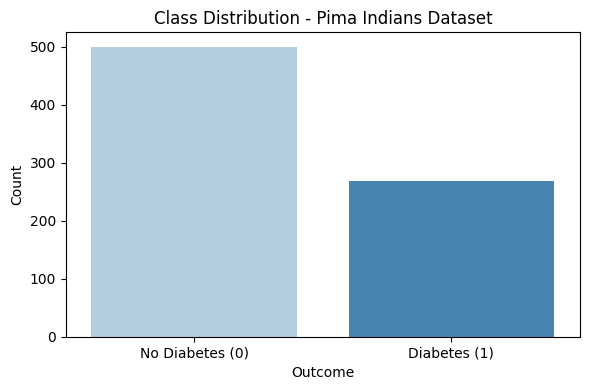

Plot saved.


In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Blues')
plt.title('Class Distribution - Pima Indians Dataset')
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('pima_class_distribution.png')
plt.show()

print("Plot saved.")

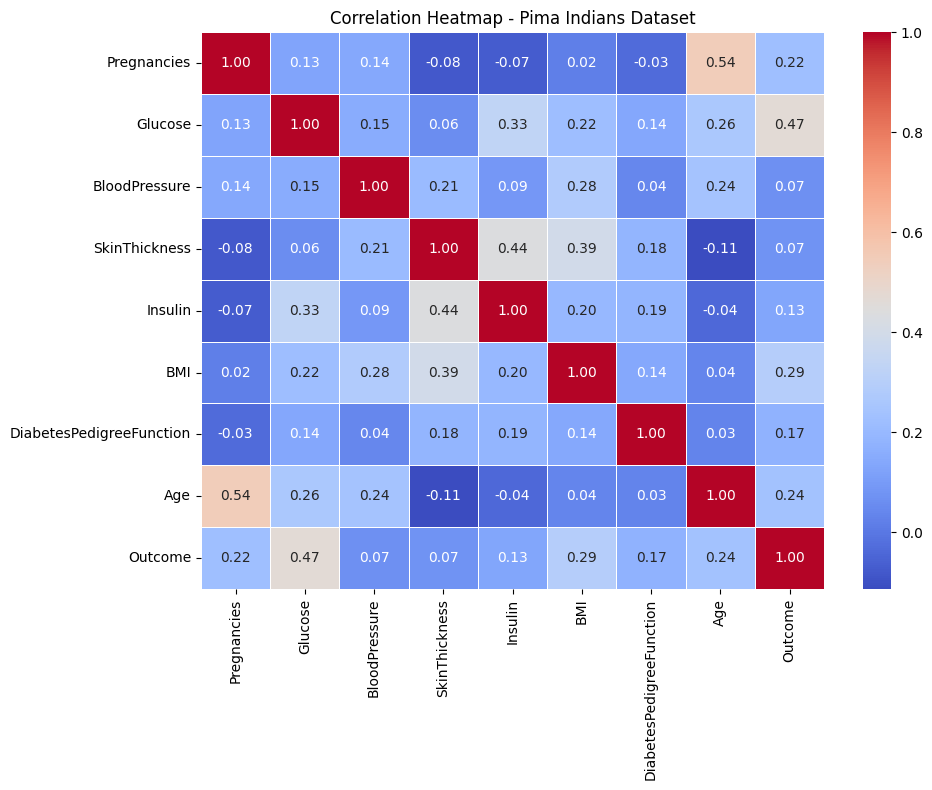

Plot saved.


In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Pima Indians Dataset')
plt.tight_layout()
plt.savefig('pima_correlation_heatmap.png')
plt.show()

print("Plot saved.")

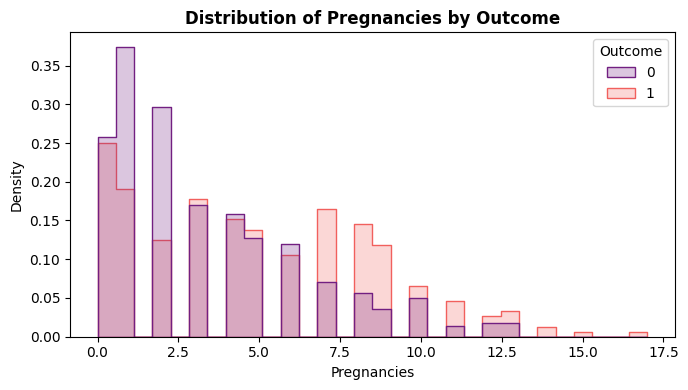

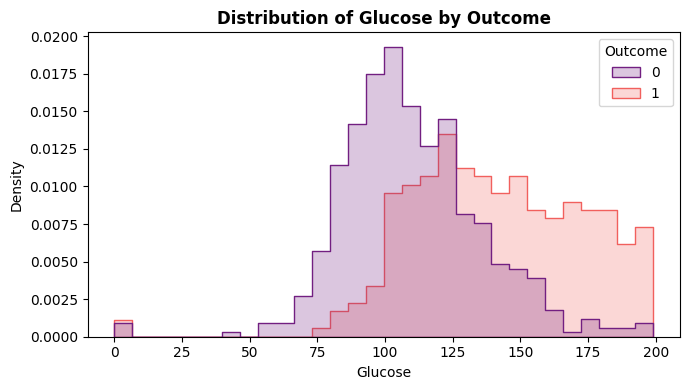

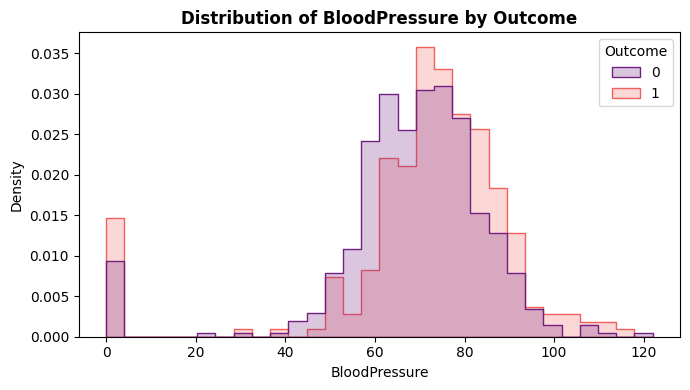

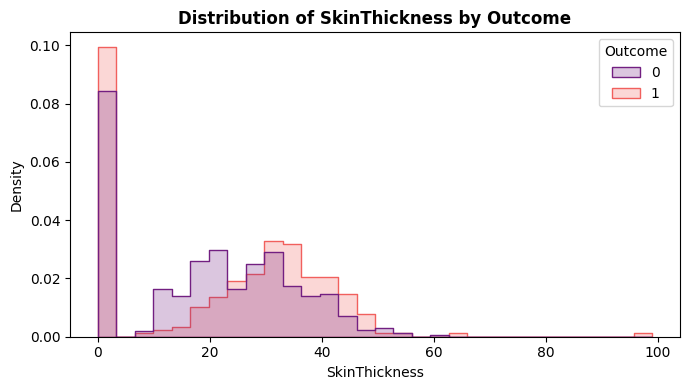

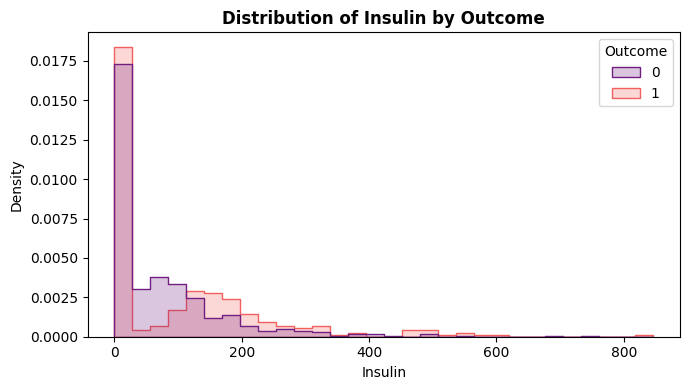

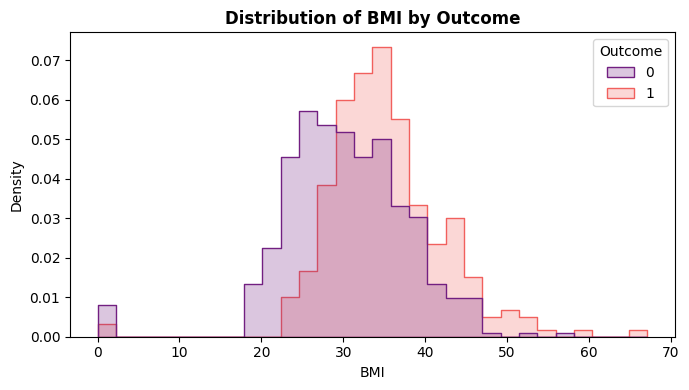

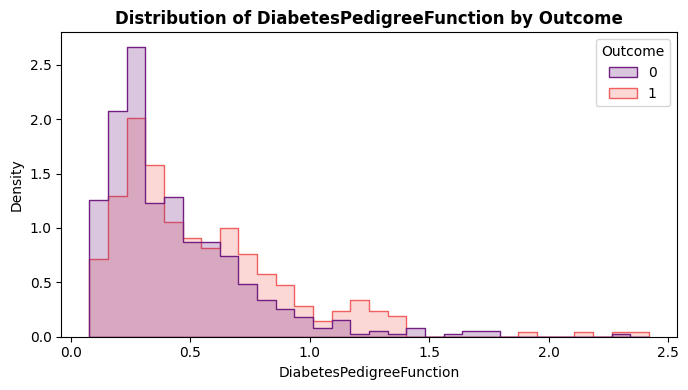

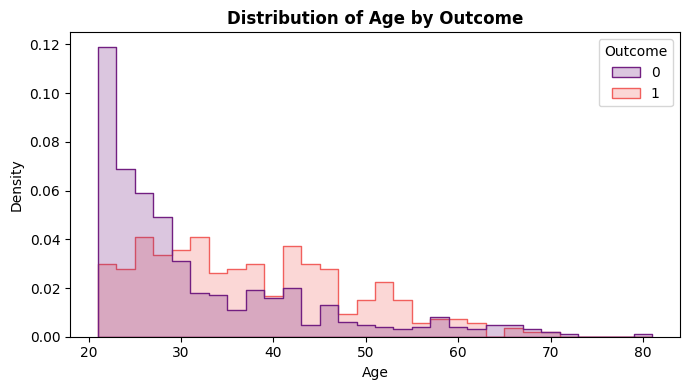

In [16]:
feature_columns = [col for col in df.columns if col != "Outcome"]

for col in feature_columns:
    plt.figure(figsize=(7, 4))

    if df[col].nunique() <= 10:
        sns.histplot(
            data=df,
            x=col,
            hue="Outcome",
            multiple="dodge", 
            discrete=True,
            shrink=0.8,
            palette="magma"
        )
        plt.ylabel("Count")
    
    else:
        sns.histplot(
            data=df,
            x=col,
            hue="Outcome",
            bins=30,
            stat="density",
            common_norm=False,
            element="step",   
            palette="magma"
        )
        plt.ylabel("Density")

    plt.title(f"Distribution of {col} by Outcome", fontweight="bold")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Preprocessing Pipeline - Pima Dataset

In [17]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("Missing values after replacing zeros with NaN:")
for col in cols_with_zeros:
    missing = df[col].isnull().sum()
    percentage = (missing / len(df)) * 100
    print(f"{col}: {missing} missing values ({percentage:.1f}%)")

Missing values after replacing zeros with NaN:
Glucose: 5 missing values (0.7%)
BloodPressure: 35 missing values (4.6%)
SkinThickness: 227 missing values (29.6%)
Insulin: 374 missing values (48.7%)
BMI: 11 missing values (1.4%)


In [18]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print(f"\nClass distribution in train:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())


Training set size: (614, 8)
Test set size: (154, 8)

Class distribution in train:
Outcome
0    400
1    214
Name: count, dtype: int64

Class distribution in test:
Outcome
0    100
1     54
Name: count, dtype: int64


In [19]:
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X.columns)

print("Median values used for imputation:")
for col, median in zip(X.columns, imputer.statistics_):
    print(f"{col}: {median:.2f}")

Median values used for imputation:
Pregnancies: 3.00
Glucose: 117.00
BloodPressure: 72.00
SkinThickness: 29.00
Insulin: 125.00
BMI: 32.40
DiabetesPedigreeFunction: 0.38
Age: 29.00


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("X_trained statistics after scaling:")
print(X_train_scaled.describe().loc[['mean', 'std', 'min', 'max']].round(2))

X_trained statistics after scaling:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
mean        -0.00    -0.00           0.00          -0.00    -0.00  0.00   
std          1.00     1.00           1.00           1.00     1.00  1.00   
min         -1.15    -2.19          -3.92          -2.48    -1.56 -2.09   
max          3.98     2.58           4.07           7.87     7.70  5.08   

      DiabetesPedigreeFunction   Age  
mean                     -0.00 -0.00  
std                       1.00  1.00  
min                      -1.19 -1.05  
max                       5.61  4.03  


In [24]:
import os
os.makedirs('../data/preprocessed/pima_preprocessed', exist_ok=True)

X_train_scaled.to_csv('../data/preprocessed/pima_preprocessed/pima_X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/preprocessed/pima_preprocessed/pima_X_test_scaled.csv', index=False)
y_train.to_csv('../data/preprocessed/pima_preprocessed/pima_y_train.csv', index=False)
y_test.to_csv('../data/preprocessed/pima_preprocessed/pima_y_test.csv', index=False)
print("Preprocessing complete. Files saved")

Preprocessing complete. Files saved
